# E-Commerce Sales Analysis

## Objective
Analyze transaction data to understand revenue trends, discount impact, and category performance.

Dataset: Kaggle E-Commerce Dataset (https://www.kaggle.com/datasets/steve1215rogg/e-commerce-dataset)

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [128]:
df = pd.read_csv("../data/raw/ecommerce_dataset_updated.csv")
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


## Data Inspection

In [129]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   str    
 1   Product_ID        3660 non-null   str    
 2   Category          3660 non-null   str    
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   str    
 7   Purchase_Date     3660 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 228.9 KB


,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


## Data Preparation

In [130]:
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"],format="%d-%m-%Y")
df["Purchase_Date"].head()

0   2024-11-12
1   2024-02-09
2   2024-09-01
3   2024-04-01
4   2024-09-27
Name: Purchase_Date, dtype: datetime64[us]

In [131]:
df.rename(columns={"Final_Price(Rs.)": "Revenue"}, inplace=True)
df["Revenue"].head()

0     31.05
1    186.23
2    237.76
3    129.89
4    195.84
Name: Revenue, dtype: float64

In [132]:
# Revenue saved from discount
df["Revenue_Saved"] = df["Price (Rs.)"] - df["Revenue"]

# Discount buckets for analysis
df["Discount_Bucket"] = pd.cut(
    df["Discount (%)"],
    bins=[-1,0,10,20,30,50],
    labels=["No Discount","1-10%","11-20%","21-30%","30%+"]
)

# Month + Year for time analysis
df["Month"] = df["Purchase_Date"].dt.to_period("M").astype(str)

df["Month_Name"] = df["Purchase_Date"].dt.month_name()

df

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Revenue,Payment_Method,Purchase_Date,Revenue_Saved,Discount_Bucket,Month,Month_Name
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12,5.48,11-20%,2024-11,November
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09,46.56,11-20%,2024-02,February
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01,79.26,21-30%,2024-09,September
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01,43.30,21-30%,2024-04,April
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27,48.96,11-20%,2024-09,September
...,...,...,...,...,...,...,...,...,...,...,...,...
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,2024-05-14,0.00,No Discount,2024-05,May
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,2024-11-19,31.93,11-20%,2024-11,November
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,2024-08-07,0.00,No Discount,2024-08,August
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,2024-05-21,134.30,21-30%,2024-05,May


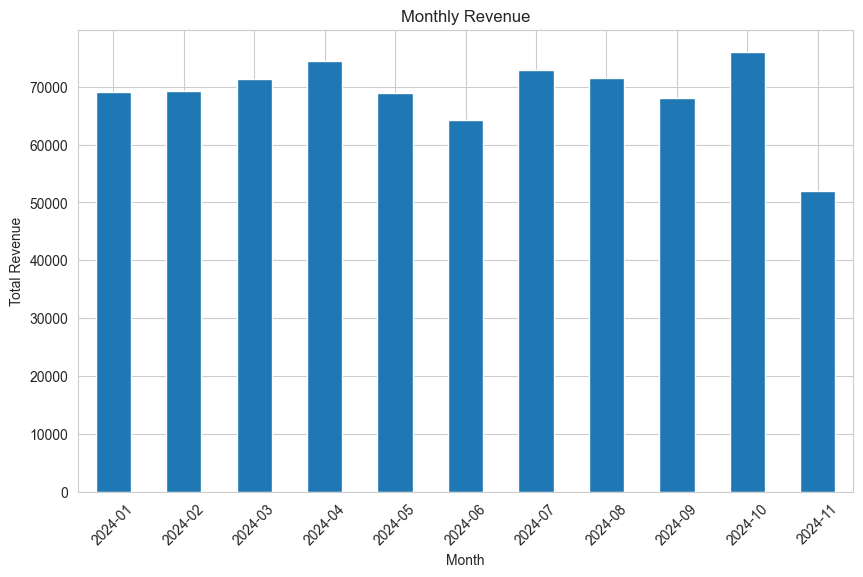

In [133]:
# Create Month column
df["Month"] = df["Purchase_Date"].dt.to_period("M")

# Calculate monthly revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue = monthly_revenue.sort_index()

monthly_revenue.head()

monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

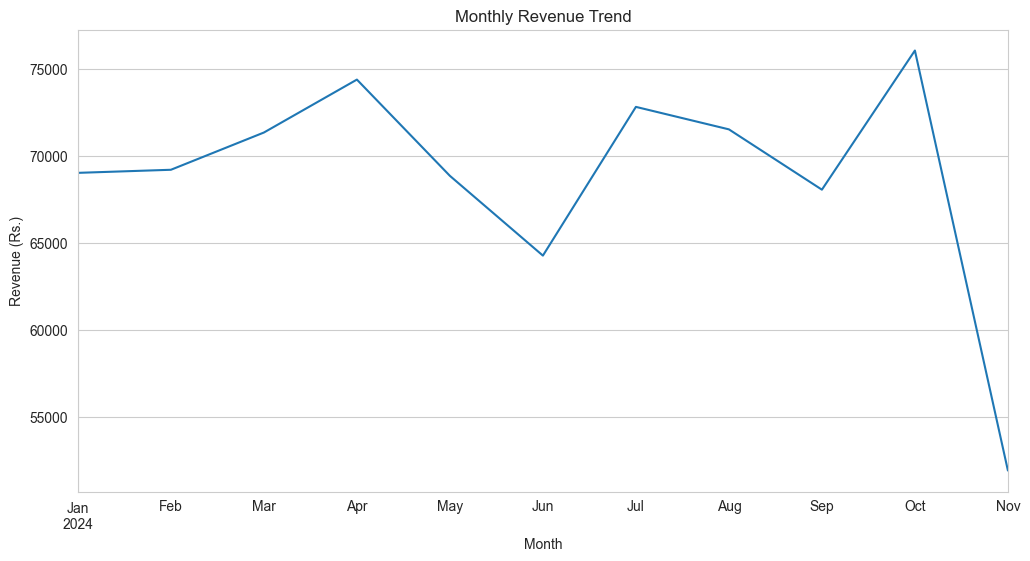

In [134]:
plt.figure(figsize=(12,6))
monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs.)")

plt.show()

Seasons

Winter: December, January, February

Spring: March, April, May

Summer: June, July, August

Autumn: September, October, November

Are sales increasing or decreasing?

Revenue shows moderate volatility across months, with mid-year dips followed by recovery in Q4.

Are there seasonal spikes?

Revenue shows mild cyclical behavior, with dips observed at seasonal transitions followed by recovery periods.

Best season was spring. Worse season was Autumn.

Which months perform best?

Best months: April, July, October

Worst months: June, September, November

In [135]:
payment_counts = df["Payment_Method"].value_counts()
payment_counts

Payment_Method
Credit Card         760
UPI                 757
Debit Card          731
Net Banking         716
Cash on Delivery    696
Name: count, dtype: int64

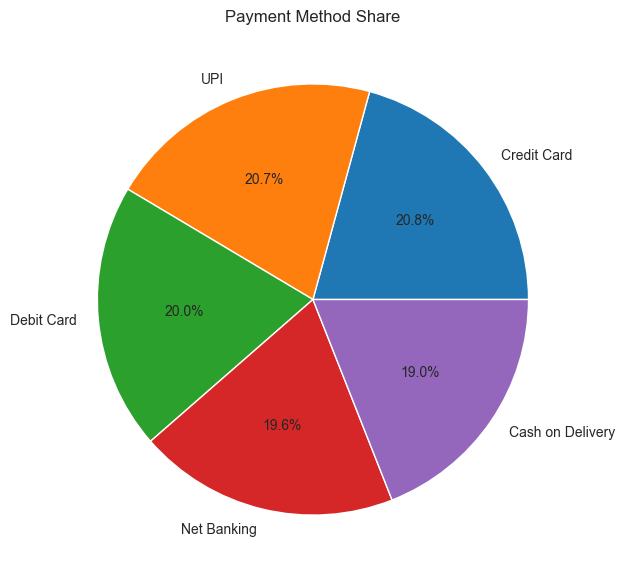

In [136]:
plt.figure(figsize=(7,7))

payment_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method Share")
plt.ylabel("")
plt.show()

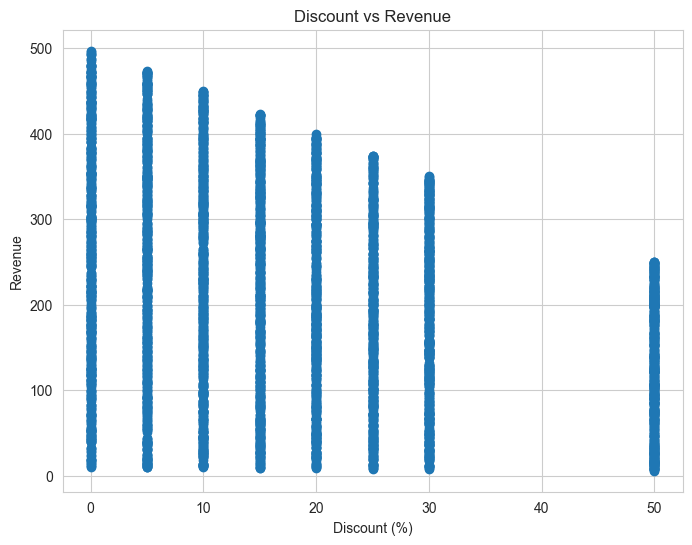

In [137]:
plt.figure(figsize=(8,6))

plt.scatter(df["Discount (%)"], df["Revenue"])

plt.title("Discount vs Revenue")
plt.xlabel("Discount (%)")
plt.ylabel("Revenue")

plt.show()

In [138]:
correlation = df[["Revenue", "Discount (%)", "Price (Rs.)"]].corr()
correlation

,Revenue,Discount (%),Price (Rs.)
Revenue,1.000000,-0.311515,0.935691
Discount (%),-0.311515,1.000000,-0.003473
Price (Rs.),0.935691,-0.003473,1.000000


Do higher discounts lead to higher spending?

No

Is there a “sweet spot” discount?

Discounts between 10–20% generated higher transaction frequency without significantly reducing revenue.

Do extreme discounts reduce revenue?

Yes, the higher the discount the lower the revenue since it has a -0.31 negative relationship.

Based on the 0.93 correlation it means that revenue is primarily influenced by product pricing rather than discount variation.

Discounts are applied independently of product price since their relationship is unrelated.

In [139]:
# Sum revenue per category
revenue_by_category = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
revenue_by_category

Category
Clothing          115314.84
Books             111149.35
Home & Kitchen    110328.08
Sports            108518.79
Toys              107289.69
Beauty            104215.10
Electronics       100462.23
Name: Revenue, dtype: float64

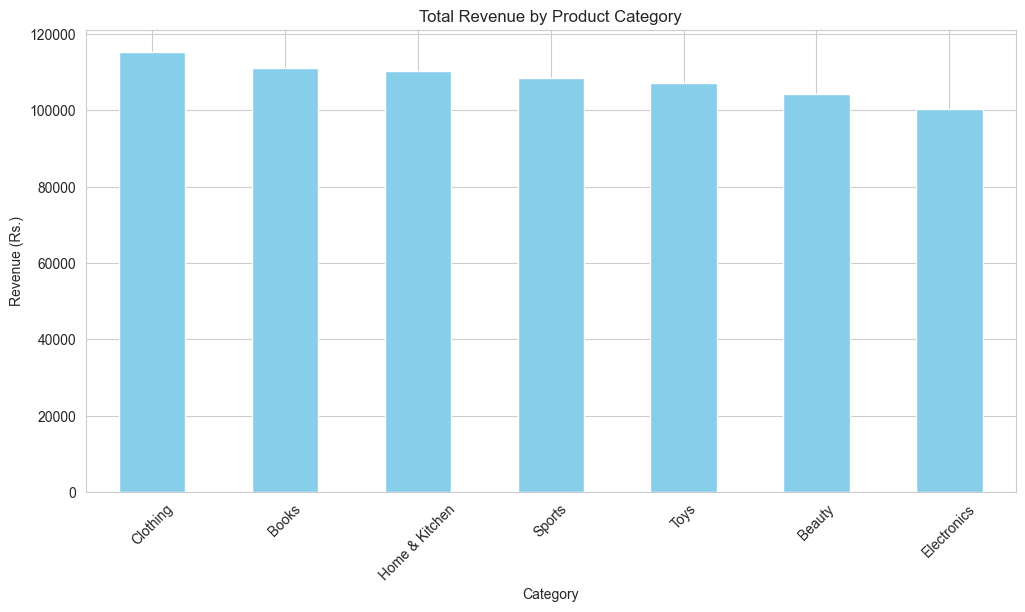

In [140]:
plt.figure(figsize=(12,6))
revenue_by_category.plot(kind="bar", color="skyblue")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (Rs.)")
plt.xticks(rotation=45)

plt.show()

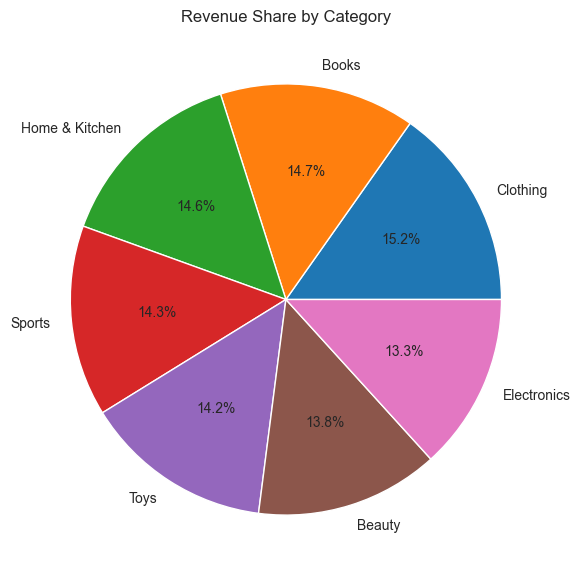

In [141]:
plt.figure(figsize=(7,7))
revenue_by_category.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Share by Category")
plt.ylabel("")
plt.show()

Clothing contributed the highest revenue, followed by Books and Home & Kitchen, indicating where the company should focus marketing and inventory efforts.

In [142]:
df.to_csv("../data/processed/ecommerce_analysis_ready.csv", index=False)

## Key Insights

- Revenue is primarily driven by product price (strong positive correlation).
- Aggressive discounting negatively impacts revenue.
- Moderate discounts (10–20%) balance volume and profitability.
- Clothing is the highest revenue-generating category.

## Conclusion

This analysis evaluated revenue trends, pricing dynamics, and category performance using transaction-level e-commerce data.

Revenue is strongly driven by product price (correlation = 0.94), indicating that higher-priced items contribute disproportionately to total sales. Discount percentage shows a moderate negative relationship with revenue (-0.31), suggesting that aggressive discounting does not increase overall revenue and may reduce total sales value.

Additionally, discount levels appear independent of product price, implying that pricing strategy may not be optimized relative to item value.

Overall, the findings suggest that maintaining controlled discount ranges (10–20%) and focusing on high-value product categories would likely produce more stable revenue outcomes than increasing discount intensity.